In [35]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
from sdv.metadata import SingleTableMetadata
# from sdv.single_table import CopulaGANSynthesizer, TVAESynthesizer, CTGANSynthesizer
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import shap


import optuna

device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

import warnings
warnings.filterwarnings('ignore')

In [36]:
data = pd.read_csv('Data/walmart_cleaned.csv')

In [37]:
data['Date'] = pd.to_datetime(data['Date'])
data['day'] = data['Date'].dt.day
data['month'] = data['Date'].dt.month
data['year'] = data['Date'].dt.year
data = data.sort_values(by='Date').reset_index(drop=True)
# data = data.drop(['Date', 'Unnamed: 0', 'Store'], axis=1)

<Axes: xlabel='Date'>

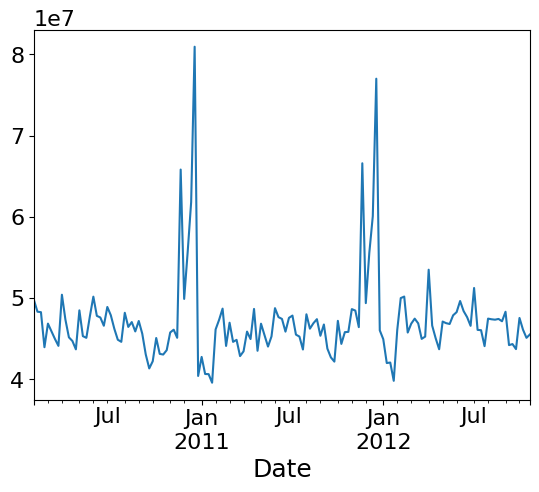

In [38]:
data.groupby('Date').sum()['Weekly_Sales'].plot()

In [39]:
data = data.drop(['Unnamed: 0', 'Date', 'Store',  'Type', 'Dept',
                  'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Size'], axis=1)

In [ ]:
cat_cols_name = ['IsHoliday', 'day', 'month', 'year']
num_cols_name = ['Weekly_Sales', 'Fuel_Price', 'CPI', 'Unemployment', 'Temperature']

In [41]:
pd.concat([data.drop('Weekly_Sales', axis=1), data[['Weekly_Sales']]], axis=1)

,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,day,month,year,Weekly_Sales
0,0,42.31,2.572,211.096358,8.106,5,2,2010,24924.50
1,0,27.19,2.784,135.352461,9.262,5,2,2010,5015.30
2,0,27.19,2.784,135.352461,9.262,5,2,2010,62831.98
3,0,27.19,2.784,135.352461,9.262,5,2,2010,10870.40
4,0,27.19,2.784,135.352461,9.262,5,2,2010,345.00
...,...,...,...,...,...,...,...,...,...
421565,0,46.97,3.755,131.193097,5.621,26,10,2012,127416.33
421566,0,46.97,3.755,131.193097,5.621,26,10,2012,2820.28
421567,0,46.97,3.755,131.193097,5.621,26,10,2012,40228.51
421568,0,41.80,3.686,199.219532,6.195,26,10,2012,26750.82


In [28]:
X = data.drop('Weekly_Sales', axis=1)
y = data['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=55555)


In [29]:
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [30]:
xgb_pred = xgb.predict(X_test)

In [31]:
mean_absolute_percentage_error(y_test.values, xgb_pred), r2_score(y_test.values, xgb_pred)

(1689577690323765.8, 0.9385525147119975)

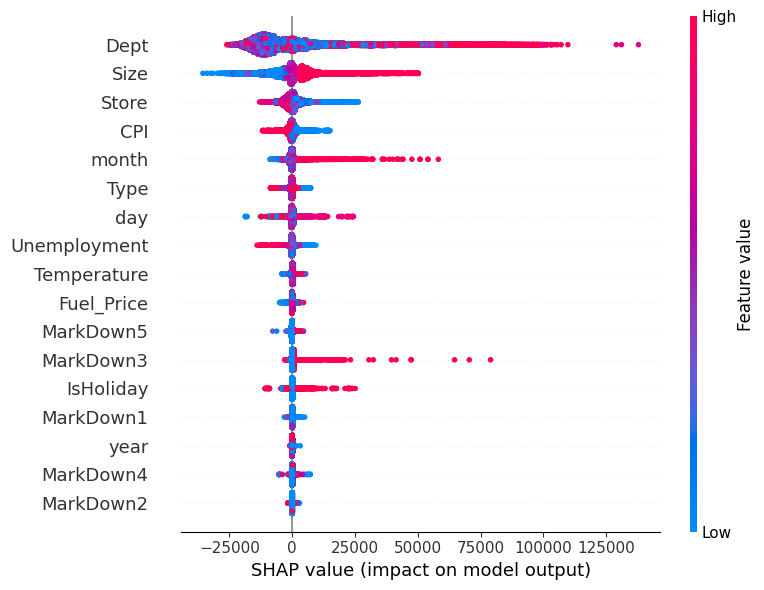

In [32]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_test)
shap.summary_plot(explanation, plot_size=[8,6])

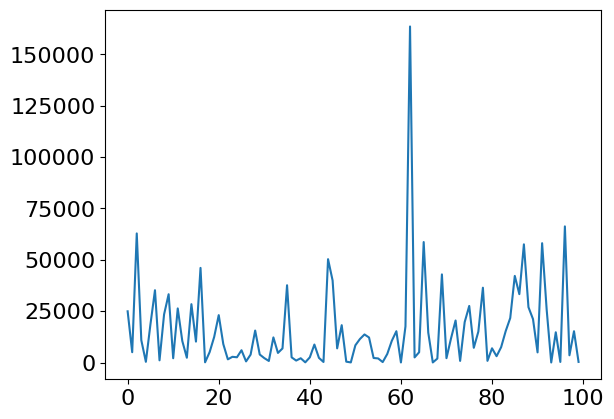

In [33]:
plt.plot(y[:100])

plt.show()